## Setup

In [ ]:
import os
import h5py
import glob
import math
import webdataset as wds
import pandas as pd
import numpy as np

from utils.constant import *
from utils.paths import *


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import umap

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except ModuleNotFoundError:
    print("Not running on Google Colab. Skipping Drive mount.")

Mounted at /content/drive


In [55]:
RES_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RES_DIR, exist_ok=True)

## UMAP

In [56]:
os.makedirs(os.path.join(RES_DIR, 'umap'), exist_ok=True)

In [57]:
def load_features(model_name, mse_targets=MSE_TARGETS):
    features_dict = {}
    labels_dict = {}

    for split in ['train', 'test']:
        clean_path = get_clean_features_path(model_name, split)
        with h5py.File(clean_path, "r") as f:
            features_dict[split] = f['features'][:]
            labels_dict[split] = f['labels'][:]

    for psnr, mse in MSE_TARGETS.items():
        adv_path = get_adv_features_path(model_name, model_name, 'test', psnr)
        with h5py.File(adv_path, "r") as f:
            features_dict[psnr] = f['features'][:]
            labels_dict[psnr] = f['labels'][:]
    return features_dict, labels_dict

In [58]:
def plot_umap_progression(model_name, features_dict, labels_dict, class_names, save_path, seed=SEED):
    embeddings = []
    labels= []
    titles= []

    reducer = umap.UMAP(n_neighbors=50, min_dist=0.5, n_components=2, random_state=seed, n_jobs=1)
    print(f"[UMAP] Fitting and transforming train set...")
    embeddings += [reducer.fit_transform(features_dict['train'])]
    labels += [labels_dict['train']]
    titles += [f"{model_name}: Train (Clean)"]

    for i in features_dict:
        if i == 'train':
            continue

        print(f"[UMAP] Transforming {i}...")
        embeddings += [reducer.transform(features_dict[i])]
        labels += [labels_dict[i]]
        if i == 'test':
            titles += [ f"{model_name}: Test (Clean)"]
        else:
            titles += [ f"{model_name}: Test (Attacked, PSNR {i})"]

    fig, axes = plt.subplots(1, 5, figsize=(30, 6.5), sharex=True, sharey=True)
    for ax, emb, lab, title in zip(axes, embeddings, labels, titles):
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=lab, palette="tab10", alpha=0.7, s=12, ax=ax, legend=(ax is axes[0]))
        ax.set_title(title, fontsize=20)
        ax.set_xlabel("UMAP dimension 1", fontsize=20)
        ax.set_ylabel("UMAP dimension 2", fontsize=20)
        ax.grid(True, linestyle="--", alpha=0.3)

    handles, labels_int = axes[0].get_legend_handles_labels()
    labels_named = [class_names[int(l)] for l in labels_int]
    axes[0].get_legend().remove()
    fig.legend(handles, labels_named, bbox_to_anchor=(1.01, 0.85), loc='upper left', fontsize=20, markerscale=2.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Save to: {save_path}")

    plt.show()
    return fig

In [59]:
for model_name in SUPPORTED_MODELS:
    features_dict, labels_dict = load_features(model_name)
    save_path = os.path.join(BASE_DIR, 'results', 'umap', f'{model_name}_wb_attack.png')
    plot_umap_progression(model_name, features_dict, labels_dict, IDS_TO_LABELS, save_path)

Output hidden; open in https://colab.research.google.com to view.

## Quantification of Embedding Shift through Cosine Similarity


In [60]:
EMB_METRICS_DIR = 'embed_shift'
os.makedirs(os.path.join(RES_DIR, EMB_METRICS_DIR), exist_ok=True)

In [61]:
def load_features(path):
    with h5py.File(path, "r") as f:
        features = f['features'][:]
        labels = f['labels'][:]
    return features, labels

In [62]:
def compute_cossim_stats(feat_clean, feat_adv):
    feat_clean_t = torch.from_numpy(feat_clean).float()
    feat_adv_t = torch.from_numpy(feat_adv).float()

    cossim = F.cosine_similarity(feat_clean_t, feat_adv_t, dim=-1).numpy()

    return {
        "cossim_mean": cossim.mean(),
        "cossim_std": cossim.std(),
        "cossim_median": np.median(cossim),
        "cossim_min": cossim.min(),
        "cossim_max": cossim.max(),
        "n_samples": len(cossim),
    }

In [63]:
results = []
for model_name in SUPPORTED_MODELS:
    path_clean_test = get_clean_features_path(model_name, 'test')
    feat_clean_test, labels_clean_test = load_features(path_clean_test)

    for psnr, mse_val in MSE_TARGETS.items():
        path_adv = get_adv_features_path(model_name, model_name, 'test', psnr)
        feat_adv, labels_adv = load_features(path_adv)

        assert feat_clean_test.shape[0] == feat_adv.shape[0], f"Mismatch in number of samples between clean and adv features"
        assert np.array_equal(labels_clean_test, labels_adv), f"Mismatch between clean and adv labels"

        stats = compute_cossim_stats(feat_clean_test, feat_adv)
        stats["model"] = model_name
        stats["psnr"] = psnr
        stats["mse_target"] = mse_val

        results.append(stats)
df_results = pd.DataFrame(results)
df_results = df_results[["model", "psnr", "mse_target", "cossim_mean", "cossim_std", "cossim_median", "cossim_min", "cossim_max", "n_samples"]]
display(df_results)
df_results.to_csv(os.path.join(RES_DIR, EMB_METRICS_DIR, "cossim_results.csv"), index=False)

,model,psnr,mse_target,cossim_mean,cossim_std,cossim_median,cossim_min,cossim_max,n_samples
0,uni_v1,45dB,0.000032,0.469937,0.129860,0.474705,-0.105549,0.999985,7680
1,uni_v1,40dB,0.000100,0.109328,0.138962,0.108232,-0.476598,0.639069,7680
2,uni_v1,35dB,0.000316,-0.332629,0.123189,-0.338838,-0.731335,0.269354,7680
3,conch_v1,45dB,0.000032,0.382164,0.276947,0.393697,-0.631137,0.937528,7680
4,conch_v1,40dB,0.000100,-0.342220,0.332259,-0.388414,-0.970456,0.828262,7680
5,conch_v1,35dB,0.000316,-0.956816,0.059673,-0.973867,-0.994227,-0.100235,7680
6,virchow_v1,45dB,0.000032,0.543610,0.347408,0.405972,-0.184058,0.999997,7680
7,virchow_v1,40dB,0.000100,0.142834,0.310052,0.065006,-0.334323,0.999992,7680
8,virchow_v1,35dB,0.000316,-0.240109,0.141014,-0.254763,-0.494598,0.999962,7680


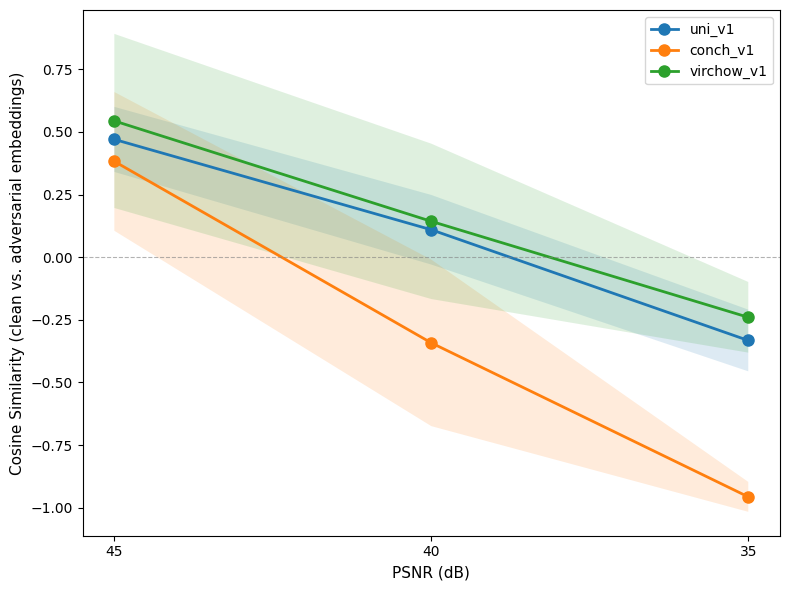

In [64]:
df = pd.read_csv(os.path.join(RES_DIR, EMB_METRICS_DIR, "cossim_results.csv"))
budget_order = list(MSE_TARGETS.keys())
psnr_values = [45, 40, 35]

fig, ax = plt.subplots(figsize=(8, 6))

for model in df["model"].unique():
    df_model = df[df["model"] == model].set_index("psnr").loc[budget_order]
    mean = df_model["cossim_mean"].values
    std = df_model["cossim_std"].values

    ax.plot(psnr_values, mean, marker='o', linewidth=2, markersize=8, label=model)
    ax.fill_between(psnr_values, mean - std, mean + std, alpha=0.15)

ax.invert_xaxis()
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xticks(psnr_values)
ax.set_xlabel("PSNR (dB)", fontsize=11)
ax.set_ylabel("Cosine Similarity (clean vs. adversarial embeddings)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, EMB_METRICS_DIR,"cossim_results.png"), dpi=300, bbox_inches='tight')
plt.show()

## Assessment of Representation Separability through Linear Probing

In [65]:
LP_DIR = os.path.join(RES_DIR, 'linear_probe')
os.makedirs(LP_DIR, exist_ok=True)

CKPT_DIR = os.path.join(LP_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

EVAL_CLEAN_F = 'eval_clean.csv'
EVAL_CLEAN_DEF_F = 'eval_clean_def.csv'
EVAL_ADV_F = 'eval_adv.csv'
EVAL_ADV_DEF_F = 'eval_adv_def.csv'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [66]:
def seed_torch(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_torch(SEED)

In [67]:
class FeatureDataset(Dataset):
    def __init__(self, h5_path):
        with h5py.File(h5_path, 'r') as f:
            self.features = torch.tensor(f['features'][:], dtype=torch.float32)
            self.labels = torch.tensor(f['labels'][:], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

class LinearProbe(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        logits = self.fc(x)
        probs = F.softmax(logits, dim=1)
        return {'logits': logits, 'probs': probs}

In [68]:
def train(model, train_loader, val_loader, ckpt_save_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    num_epochs = 30
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    best_val_bal_acc = 0.0
    best_epoch = -1
    for epoch in range(num_epochs):
        # --- [Train] --- #
        model.train()
        train_loss = 0.0
        train_num_samples = 0
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            output = model(features)
            logits = output['logits']
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * features.size(0)
            train_num_samples += features.shape[0]
        train_loss /= train_num_samples

        # --- [Validation] --- #
        model.eval()
        val_loss = 0.0
        val_num_samples = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                output = model(features)
                logits = output['logits']
                loss = criterion(logits, labels)
                val_loss += loss.item() * features.size(0)
                val_num_samples += features.shape[0]

                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        val_loss /= val_num_samples
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_bal_acc = balanced_accuracy_score(all_labels, all_preds)

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val bal_acc: {val_bal_acc:.4f}")

        # --- [Model Checkpoint] --- #
        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_save_path)

    # --- [Load the model with the best validation balanced accuracy] --- #
    if best_epoch != -1:
        print(f'Model checkpoint saved to: {ckpt_save_path}')
        model.load_state_dict(torch.load(ckpt_save_path, map_location=device))
        print(f"Best model loaded from Epoch {best_epoch+1} with validation balanced accuracy {best_val_bal_acc:.3f}")
    return model

In [69]:
def run_lp_training(model_name):
    print(f'\n[LINEAR PROBING] Training on {model_name} clean features...')
    train_clean_feat = get_clean_features_path(model_name, 'train')
    val_clean_feat = get_clean_features_path(model_name, 'valid')

    train_dataset  = FeatureDataset(train_clean_feat)
    val_dataset  = FeatureDataset(val_clean_feat)

    train_dl = DataLoader(train_dataset, shuffle=True, batch_size=256)
    val_dl = DataLoader(val_dataset, shuffle=False, batch_size=256)
    embed_dim = MODEL2EMB_DIM[model_name]

    model = LinearProbe(embed_dim, NUM_CLASSES)
    ckpt_save_path = os.path.join(CKPT_DIR, f'{model_name}_linear_probe.pth')
    model = train(model, train_dl, val_dl, ckpt_save_path)
    return None

In [70]:
def evaluate(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds, all_labels = [], []
    with torch.inference_mode():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            output = model(features)
            logits = output['logits']

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return balanced_accuracy_score(all_labels, all_preds), all_preds, all_labels

In [71]:
def eval_lp_clean_test(defence, filename):
    split = 'test'
    if defence:
        sigma_list = SIGMA
    else:
        sigma_list = [None]

    results_list = []
    for model_name in SUPPORTED_MODELS:
        embed_dim = MODEL2EMB_DIM[model_name]
        model = LinearProbe(embed_dim, NUM_CLASSES)
        ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_linear_probe.pth')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

        for sigma in sigma_list:
            test_clean_feat = get_clean_features_path(model_name, split, sigma=sigma)
            test_dataset  = FeatureDataset(test_clean_feat)
            test_dl = DataLoader(test_dataset, shuffle=False, batch_size=256)

            bal_acc, _, _ = evaluate(model, test_dl)

            results_list.append({
                'target_model_name': model_name,
                'source_model_name': None,
                'split': split,
                'feature_type': 'clean',
                'psnr': None,
                'defence': defence,
                'sigma': sigma,
                'balanced_accuracy': bal_acc
            })
    df_results = pd.DataFrame(results_list)
    display(df_results)
    save_path = os.path.join(LP_DIR, filename)
    df_results.to_csv(save_path, index=False)
    if defence:
        print(f'Linear Probe Evaluation on Clean Test Set with Defense save to: {save_path}')
    else:
        print(f'Linear Probe Evaluation on Clean Test Set save to: {save_path}')

In [72]:
def eval_lp_adv_test(defence, filename):
    split = 'test'
    if defence:
        sigma_list = SIGMA
    else:
        sigma_list = [None]

    results_list = []
    for target_model_name in SUPPORTED_MODELS:
        split = 'test'
        embed_dim = MODEL2EMB_DIM[target_model_name]
        model = LinearProbe(embed_dim, NUM_CLASSES)
        ckpt_path = os.path.join(CKPT_DIR, f'{target_model_name}_linear_probe.pth')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

        for psnr, mse in MSE_TARGETS.items():
            for source_model_name in SUPPORTED_MODELS:
                if defence == True and target_model_name != source_model_name:
                    continue

                for sigma in sigma_list:

                    test_adv_feat = get_adv_features_path(target_model_name, source_model_name, split, psnr, sigma=sigma)
                    test_dataset  = FeatureDataset(test_adv_feat)
                    test_dl = DataLoader(test_dataset, shuffle=False, batch_size=256)

                    bal_acc, _, _ = evaluate(model, test_dl)

                    results_list.append({
                        'target_model_name': target_model_name,
                        'source_model_name': source_model_name,
                        'split': split,
                        'feature_type': 'adv',
                        'psnr': psnr,
                        'defence': defence,
                        'sigma': sigma,
                        'balanced_accuracy': bal_acc
                    })
    df_results = pd.DataFrame(results_list)
    display(df_results)
    save_path = os.path.join(LP_DIR, filename)
    df_results.to_csv(save_path, index=False)
    if defence:
        print(f'Linear Probe Evaluation on Attacked Test Set with Defense save to: {save_path}')
    else:
        print(f'Linear Probe Evaluation on Attacked Test Set save to: {save_path}')


Linear probe training on clean features


In [73]:
for model_name in SUPPORTED_MODELS:
    run_lp_training(model_name)


[LINEAR PROBING] Training on uni_v1 clean features...
Epoch 1/30 | Train loss: 0.2668 | Val loss: 0.1700 | Val bal_acc: 0.9448
Epoch 2/30 | Train loss: 0.0859 | Val loss: 0.1526 | Val bal_acc: 0.9494
Epoch 3/30 | Train loss: 0.0627 | Val loss: 0.1453 | Val bal_acc: 0.9502
Epoch 4/30 | Train loss: 0.0505 | Val loss: 0.1452 | Val bal_acc: 0.9510
Epoch 5/30 | Train loss: 0.0429 | Val loss: 0.1414 | Val bal_acc: 0.9515
Epoch 6/30 | Train loss: 0.0374 | Val loss: 0.1420 | Val bal_acc: 0.9530
Epoch 7/30 | Train loss: 0.0332 | Val loss: 0.1430 | Val bal_acc: 0.9539
Epoch 8/30 | Train loss: 0.0299 | Val loss: 0.1436 | Val bal_acc: 0.9522
Epoch 9/30 | Train loss: 0.0273 | Val loss: 0.1430 | Val bal_acc: 0.9552
Epoch 10/30 | Train loss: 0.0252 | Val loss: 0.1441 | Val bal_acc: 0.9545
Epoch 11/30 | Train loss: 0.0230 | Val loss: 0.1471 | Val bal_acc: 0.9545
Epoch 12/30 | Train loss: 0.0216 | Val loss: 0.1448 | Val bal_acc: 0.9557
Epoch 13/30 | Train loss: 0.0200 | Val loss: 0.1497 | Val bal_acc:

Linear Probe Evaluation on Clean Test Set

In [74]:
eval_lp_clean_test(defence=False, filename=EVAL_CLEAN_F)

,target_model_name,source_model_name,split,feature_type,psnr,defence,sigma,balanced_accuracy
0,uni_v1,None,test,clean,None,False,None,0.946741
1,conch_v1,None,test,clean,None,False,None,0.928772
2,virchow_v1,None,test,clean,None,False,None,0.947605


Linear Probe Evaluation on Clean Test Set save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/eval_clean.csv


Linear Probe Evaluation on Clean Test Set with Defense

In [75]:
eval_lp_clean_test(defence=True, filename=EVAL_CLEAN_DEF_F)

,target_model_name,source_model_name,split,feature_type,psnr,defence,sigma,balanced_accuracy
0,uni_v1,None,test,clean,None,True,0.5,0.947717
1,uni_v1,None,test,clean,None,True,1.0,0.949206
2,uni_v1,None,test,clean,None,True,1.5,0.946115
3,uni_v1,None,test,clean,None,True,2.0,0.936788
4,uni_v1,None,test,clean,None,True,2.5,0.903597
5,uni_v1,None,test,clean,None,True,3.0,0.885033
6,uni_v1,None,test,clean,None,True,3.5,0.848950
7,uni_v1,None,test,clean,None,True,4.0,0.814281
8,conch_v1,None,test,clean,None,True,0.5,0.924401
9,conch_v1,None,test,clean,None,True,1.0,0.897782


Linear Probe Evaluation on Clean Test Set with Defense save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/eval_clean_def.csv


Linear Probe Evaluation on Attacked Test Set

In [76]:
eval_lp_adv_test(defence=False, filename=EVAL_ADV_F)

,target_model_name,source_model_name,split,feature_type,psnr,defence,sigma,balanced_accuracy
0,uni_v1,uni_v1,test,adv,45dB,False,None,0.703396
1,uni_v1,conch_v1,test,adv,45dB,False,None,0.930743
2,uni_v1,virchow_v1,test,adv,45dB,False,None,0.940914
3,uni_v1,uni_v1,test,adv,40dB,False,None,0.404953
4,uni_v1,conch_v1,test,adv,40dB,False,None,0.911319
5,uni_v1,virchow_v1,test,adv,40dB,False,None,0.914661
6,uni_v1,uni_v1,test,adv,35dB,False,None,0.080539
7,uni_v1,conch_v1,test,adv,35dB,False,None,0.872003
8,uni_v1,virchow_v1,test,adv,35dB,False,None,0.903151
9,conch_v1,uni_v1,test,adv,45dB,False,None,0.892863


Linear Probe Evaluation on Attacked Test Set save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/eval_adv.csv


Linear Probe Evaluation on Attacked Test Set with Defense

In [77]:
eval_lp_adv_test(defence=True, filename=EVAL_ADV_DEF_F)

,target_model_name,source_model_name,split,feature_type,psnr,defence,sigma,balanced_accuracy
0,uni_v1,uni_v1,test,adv,45dB,True,0.5,0.745118
1,uni_v1,uni_v1,test,adv,45dB,True,1.0,0.835560
2,uni_v1,uni_v1,test,adv,45dB,True,1.5,0.870033
3,uni_v1,uni_v1,test,adv,45dB,True,2.0,0.879600
4,uni_v1,uni_v1,test,adv,45dB,True,2.5,0.852525
...,...,...,...,...,...,...,...,...
67,virchow_v1,virchow_v1,test,adv,35dB,True,2.0,0.683120
68,virchow_v1,virchow_v1,test,adv,35dB,True,2.5,0.642691
69,virchow_v1,virchow_v1,test,adv,35dB,True,3.0,0.616553
70,virchow_v1,virchow_v1,test,adv,35dB,True,3.5,0.591684


Linear Probe Evaluation on Attacked Test Set with Defense save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/eval_adv_def.csv


In [78]:
clean_df = pd.read_csv(os.path.join(LP_DIR, EVAL_CLEAN_F))
clean_def_df = pd.read_csv(os.path.join(LP_DIR, EVAL_CLEAN_DEF_F))
adv_df = pd.read_csv(os.path.join(LP_DIR, EVAL_ADV_F))
adv_def_df = pd.read_csv(os.path.join(LP_DIR, EVAL_ADV_DEF_F))

clean_accs = {
    m: clean_df[clean_df['target_model_name'] == m]['balanced_accuracy'].values[0] * 100
    for m in SUPPORTED_MODELS
}

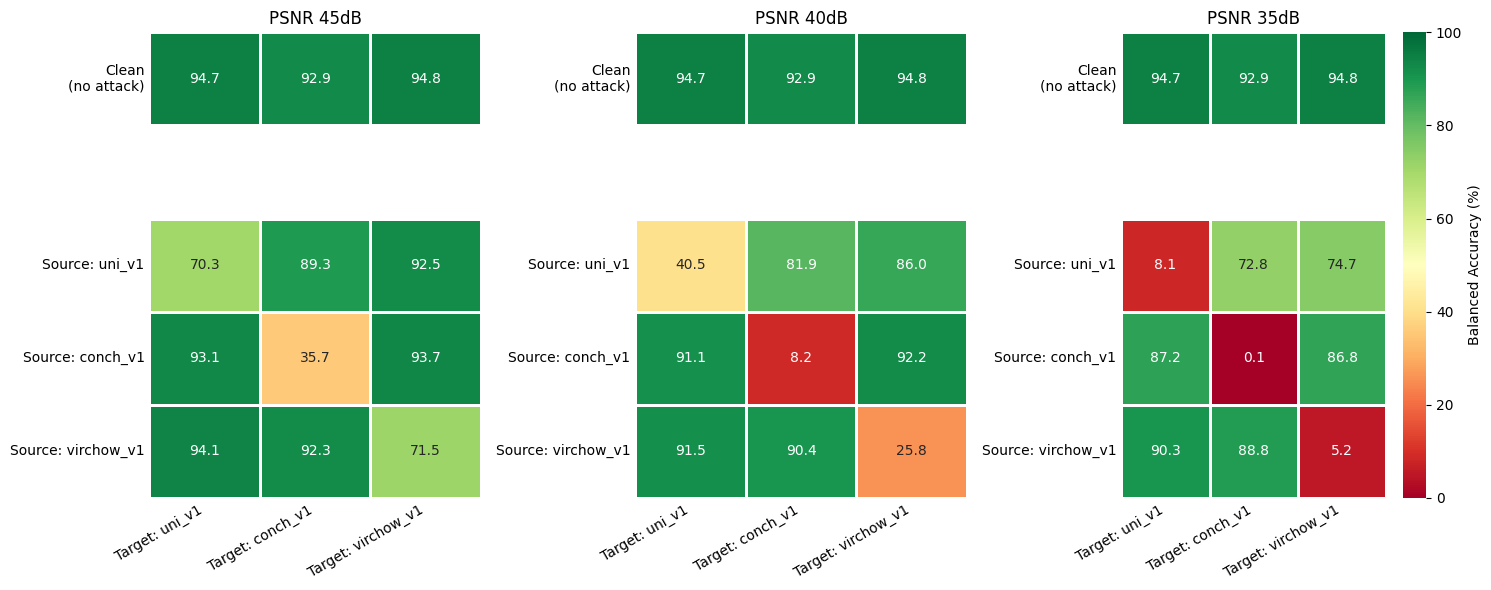

In [79]:
row_labels = ["Clean\n(no attack)", ""] + [f"Source: {m}" for m in SUPPORTED_MODELS]
col_labels = [f"Target: {m}" for m in SUPPORTED_MODELS]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, budget in enumerate(MSE_TARGETS):
    mat = np.full((len(SUPPORTED_MODELS) + 2, len(SUPPORTED_MODELS)), np.nan)

    for ti, target in enumerate(SUPPORTED_MODELS):
        mat[0, ti] = clean_accs[target]

    for si, source in enumerate(SUPPORTED_MODELS):
        for ti, target in enumerate(SUPPORTED_MODELS):
            row = adv_df[(adv_df['target_model_name'] == target) & (adv_df['source_model_name'] == source) & (adv_df['psnr'] == budget)]
            mat[si + 2, ti] = row['balanced_accuracy'].values[0] * 100

    ax = axes[i]
    mask = np.isnan(mat)
    sns.heatmap(mat, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
                xticklabels=col_labels, yticklabels=row_labels, ax=ax,
                cbar=(i == 2), linewidths=0.8, linecolor='white', mask=mask,
                cbar_kws={'label': 'Balanced Accuracy (%)'} if i == 2 else None)
    ax.add_patch(plt.Rectangle((0, 1), len(SUPPORTED_MODELS), 1, fill=True, color='white', zorder=3))

    ax.set_title(f"PSNR {budget}", fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)
    ax.tick_params(axis='both', length=0)
plt.tight_layout()
plt.savefig(os.path.join(LP_DIR, "eval_wb_bb_attack.png"), dpi=300, bbox_inches='tight')
plt.show()

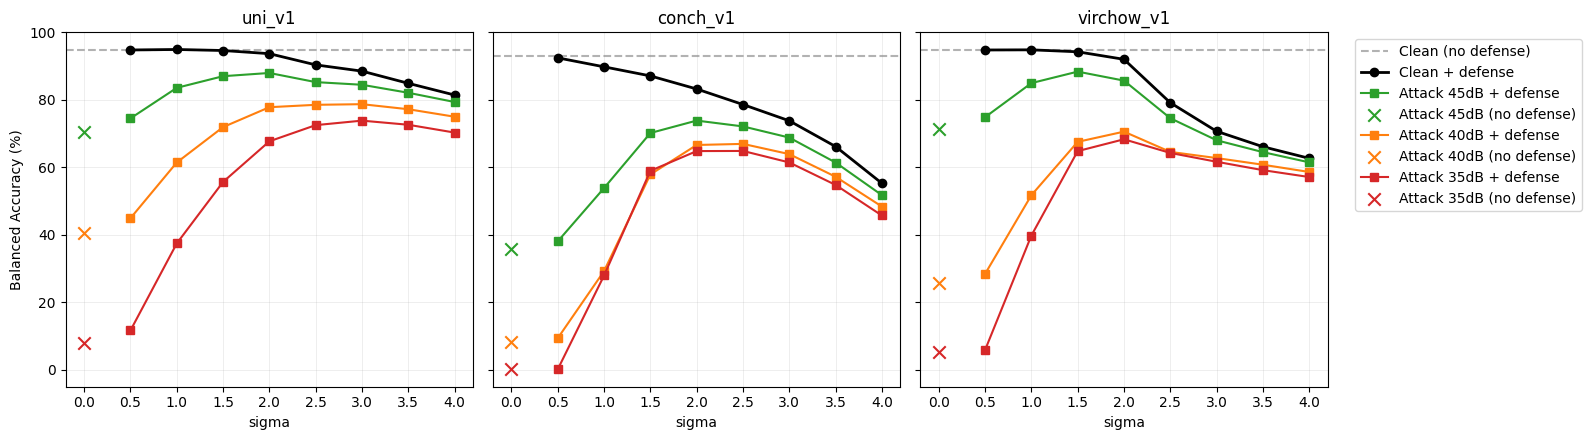

In [ ]:
colors = {'45dB':'#2ca02c', '40dB': '#ff7f0e', '35dB': '#d62728'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for i, model in enumerate(SUPPORTED_MODELS):
    ax = axes[i]
    ax.axhline(clean_accs[model], color='gray', linestyle='--', alpha=0.6, label='Clean (no defense)')

    sub_clean_def = clean_def_df[clean_def_df['target_model_name'] == model].sort_values('sigma')
    ax.plot(sub_clean_def['sigma'], sub_clean_def['balanced_accuracy'] * 100, marker='o', color='black', label='Clean + defense', linewidth=2)

    for budget in MSE_TARGETS:
        sub = adv_def_df[(adv_def_df['target_model_name'] == model) & (adv_def_df['source_model_name'] == model) & (adv_def_df['psnr'] == budget)].sort_values('sigma')
        ax.plot(sub['sigma'], sub['balanced_accuracy'] * 100, marker='s', label=f'Attack {budget} + defense', color=colors[budget])

        adv_no_def = adv_df[(adv_df['target_model_name'] == model) & (adv_df['source_model_name'] == model) & (adv_df['psnr'] == budget)]['balanced_accuracy'].values[0] * 100
        ax.scatter([0], [adv_no_def], color=colors[budget], marker='x', s=80, zorder=5, label=f'Attack {budget} (no defense)')

    ax.set_title(model)
    ax.set_xlabel("sigma", fontsize=10)
    if i == 0:
        ax.set_ylabel("Balanced Accuracy (%)", fontsize=10)
    ax.set_ylim(-5, 100)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
handles, labels = axes[-1].get_legend_handles_labels()
seen = dict(zip(labels, handles))
axes[-1].legend(seen.values(), seen.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(LP_DIR, 'eval_defenses.png'), dpi=300, bbox_inches='tight')
plt.show()

In [83]:
def plot_cm(model_name, save_path, class_names=SELECTED_CLASSES):
    preds_dict = {}
    split = 'test'
    embed_dim = MODEL2EMB_DIM[model_name]
    model = LinearProbe(embed_dim, NUM_CLASSES)
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_linear_probe.pth')
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    test_clean_feat = get_clean_features_path(model_name, split)
    test_dataset = FeatureDataset(test_clean_feat)
    test_dl = DataLoader(test_dataset, shuffle=False, batch_size=256)

    bal_acc, all_preds, all_labels = evaluate(model, test_dl)
    preds_dict['Clean'] = all_preds

    for psnr, mse in MSE_TARGETS.items():
        test_adv_feat = get_adv_features_path(model_name, model_name, split, psnr)
        test_dataset = FeatureDataset(test_adv_feat)
        test_dl = DataLoader(test_dataset, shuffle=False, batch_size=256)

        bal_acc, all_preds, all_labels = evaluate(model, test_dl)
        preds_dict[f'Attacked, PSNR {psnr}'] = all_preds


    fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))

    for i, (ax, (title, y_pred)) in enumerate(zip(axes, preds_dict.items())):
        cm = confusion_matrix(all_labels, y_pred, normalize='true')

        sns.heatmap(
            cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            vmin=0, vmax=1,
            annot_kws={"size": 14}
        )

        ax.set_title(f"{model_name}: {title}", fontsize=18, pad=12)
        ax.set_xlabel("Predicted Label", fontsize=14, labelpad=8)

        if i == 0:
            ax.set_ylabel("True Label", fontsize=14, labelpad=8)
            ax.set_yticklabels(class_names, fontsize=13, rotation=0)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Save to: {save_path}")
    plt.show()

Save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/cm_uni_v1


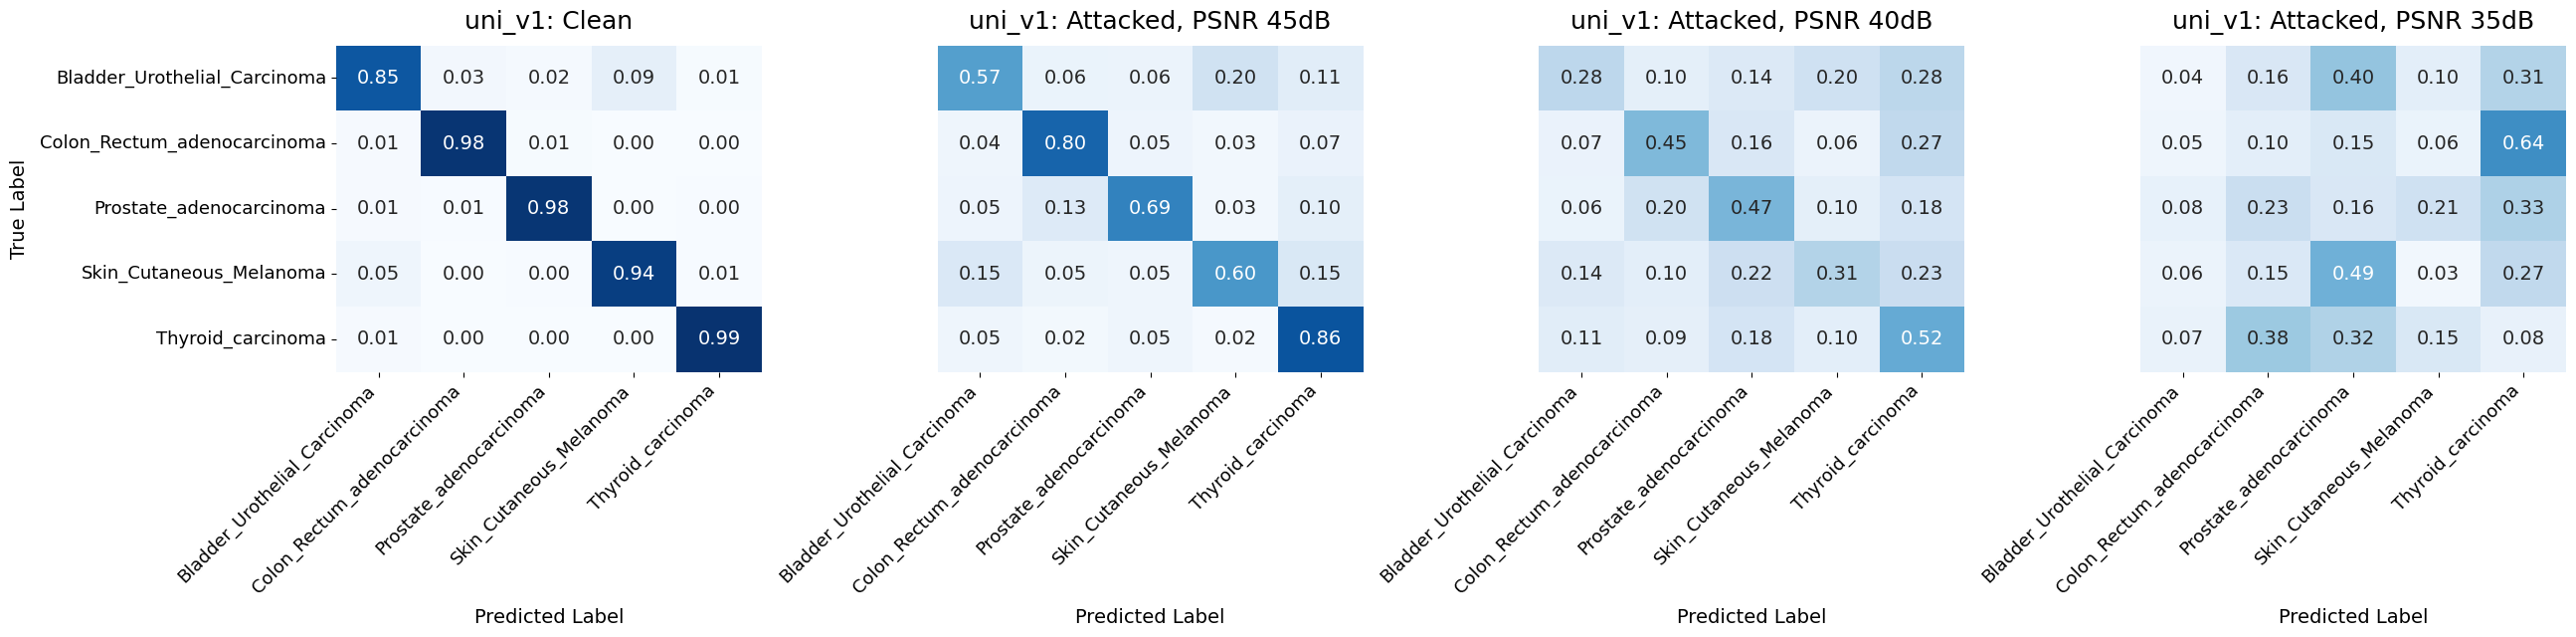

Save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/cm_conch_v1


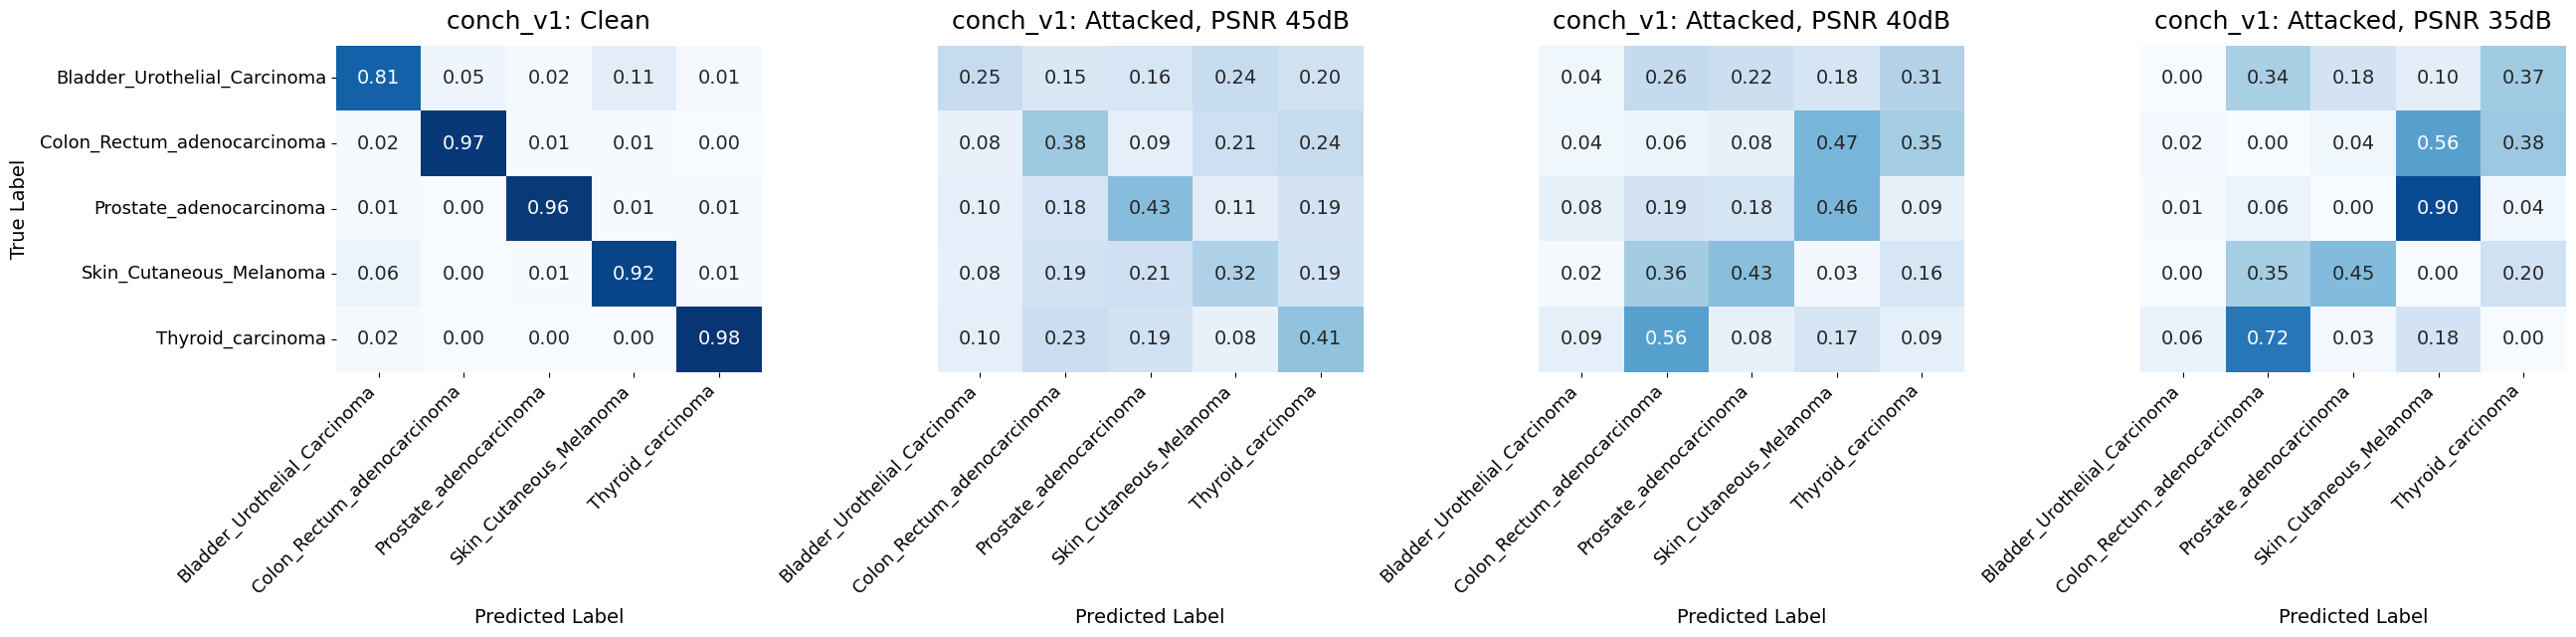

Save to: /content/drive/MyDrive/fsaa_pfms/results/linear_probe/cm_virchow_v1


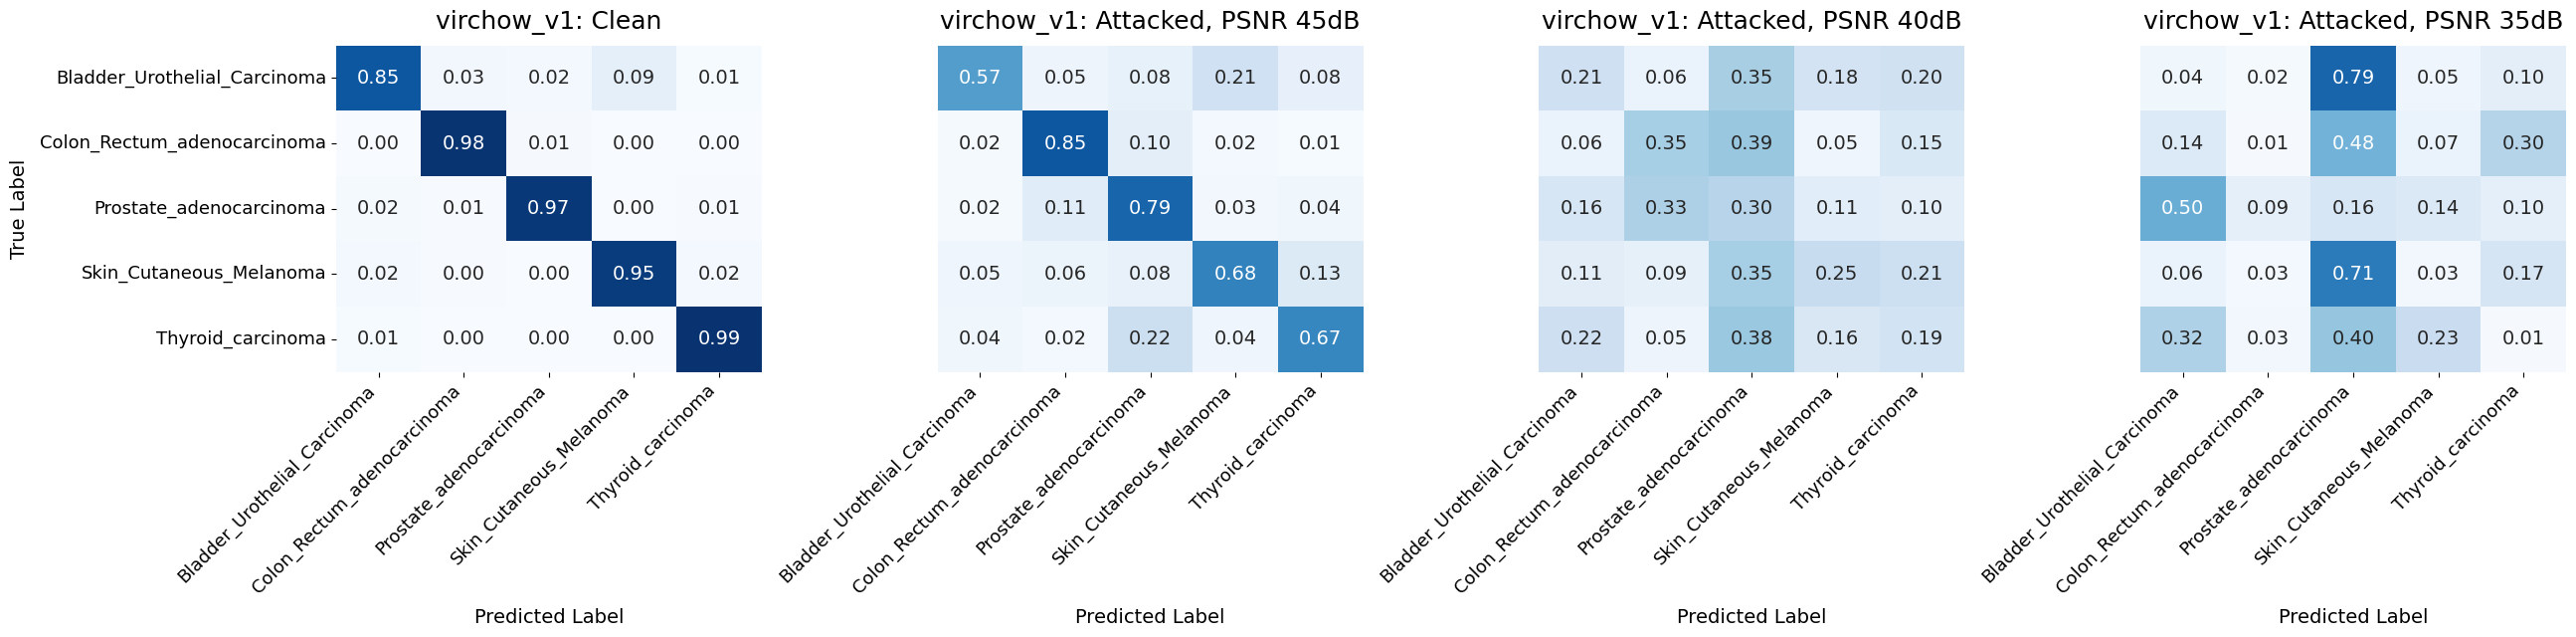

In [84]:
for model_name in SUPPORTED_MODELS:
    plot_cm(model_name, os.path.join(LP_DIR, f'cm_{model_name}'))